In [6]:
import os
import shutil
import re
from typing import Union, Dict
from pytubefix import Playlist
from Youtube.errors import (
    InvalidURLError,
    DirectoryCreationError,
    DownloadError,
    FailedDirectoryEmptyError,
)
from Youtube.yt_vid_logic import YT
from Youtube.logic_helpers import APP_PATH, handle_errors, sanitize_filename


class PL(Playlist):
    def __init__(
        self,
        url: str,
        app_path: str = APP_PATH,
        client: str = "WEB",
        proxies: Union[Dict[str, str], None] = None,
        use_oauth: bool = False,
        allow_oauth_cache: bool = True,
        token_file: Union[str, None] = None,
    ):
        super().__init__(url, client, proxies, use_oauth, allow_oauth_cache, token_file)
        self.video_handle = YT
        self.app_path = app_path
        self._title = sanitize_filename(self.title)
        self.path = f"{self.app_path}\\{self._title}"
        self.tmp = f"{self.app_path}\\{self._title}\\tmp"
        self.thumbnail_url = None
        self.thumbnail_list = []
        self._create_directories()

    def _create_directories(self):
        if not os.path.exists(self.path):
            os.makedirs(self.path, exist_ok=True)
        if not os.path.exists(self.tmp):
            os.makedirs(self.tmp, exist_ok=True)

    def download_video(self, _type: int, resolution: Union[None, int] = None):
        if not self.video_urls:
            raise DownloadError("No video URLs found in the playlist.")
        for i in self.video_urls:

            self.video_handle(i, app_path=self.path).download_video(_type, resolution)
            print(i)

        self.empty_folder(self.tmp)

    def get_thumbnail_url(self):
        return [self.video_handle(i).thumbnail_url for i in self.video_urls]

    def empty_folder(self, path: str) -> None:
        if os.path.exists(path):
            shutil.rmtree(path)

In [7]:
from typing import Callable, Union, Any, Dict
import os
import shutil
import time
import re
import ffmpeg
from pytubefix import YouTube, Stream
from Youtube.errors import (
    _FileExistsError,
    InvalidURLError,
    DirectoryCreationError,
    DownloadError,
    FailedDirectoryEmptyError,
    FFmpegError,
)
from Youtube.logic_helpers import APP_PATH, handle_errors, sanitize_filename

from pytubefix.innertube import _default_clients

_default_clients["ANDROID_MUSIC"] = _default_clients["ANDROID"]


class YT(YouTube):
    def __init__(
        self,
        url: str,
        app_path: str = APP_PATH,
        client: str = "ANDROID_TESTSUITE",
        on_progress_callback: Union[Callable[[Any, bytes, int], None], None] = None,
        on_complete_callback: Union[
            Callable[[Any, Union[str, None]], None], None
        ] = None,
        proxies: Union[Dict[str, str], None] = None,
        use_oauth: bool = True,
        allow_oauth_cache: bool = True,
        token_file: Union[str, None] = None,
    ):
        super().__init__(
            url,
            client,
            on_progress_callback,
            on_complete_callback,
            proxies,
            use_oauth,
            allow_oauth_cache,
            token_file,
        )
        self.url = url
        self._type = {1: "audio", 2: "video", 3: "both"}
        self.res = {3: "1080p", 2: "720p", 1: "480p"}
        self.t_res = ""
        self.app_path = app_path
        self._title = sanitize_filename(self.title)
        self.tmp = os.path.join(self.app_path, "tmp")
        self._create_directories()

    def get_thumbnail_url(self):
        return list(self.thumbnail_url)

    def _create_directories(self):
        if not os.path.exists(self.app_path):
            os.makedirs(self.app_path, exist_ok=True)
        if not os.path.exists(self.tmp):
            os.makedirs(self.tmp, exist_ok=True)

    def download_video(self, _type: int, resolution: Union[int, None] = None):
        self._extract_streams(_type, resolution)
        self.empty_folder(self.tmp)

    def empty_folder(self, path: str) -> None:
        if os.path.exists(path):
            shutil.rmtree(path)

    def _extract_streams(self, _type: int, resolution: Union[int, None] = None):
        self.t_res = self.res.get(resolution, "1080p")
        audio = self.streams.get_audio_only() if _type in {1, 3} else None
        video = self.streams.filter(res=self.t_res).first() if _type in {2, 3} else None
        self._processdata(_type, video, audio)

    def _processdata(self, _type: int, video: Stream = None, audio: Stream = None):
        self.millis = int(time.time() * 1000)
        v_out = os.path.join(self.tmp, f"{self.millis}.mp4")
        a_out = os.path.join(self.tmp, f"{self.millis}.mp3")
        if _type in {2, 3} and video:
            (filename, output_path) = (
                (f"{self._title}_{self.t_res}_video.mp4", self.app_path)
                if _type == 2
                else (f"{self.millis}.mp4", self.tmp)
            )
            video.download(output_path=output_path, filename=filename)
        if _type in {1, 3} and audio:
            (filename, output_path) = (
                (f"{self._title}_audio.mp3", self.app_path)
                if _type == 1
                else (f"{self.millis}.mp3", self.tmp)
            )
            audio.download(output_path=output_path, filename=filename)
        if video and audio and _type == 3:
            self._merge(v_out, a_out)
        print(f"Downloaded {self.watch_url}")

    def _merge(self, v_out: str, a_out: str):
        out_path = f"{self.app_path}\\{self._title}_{self.t_res}.mp4"
        if os.path.exists(out_path):
            raise _FileExistsError
        output = ffmpeg.output(
            ffmpeg.input(v_out),
            ffmpeg.input(a_out),
            out_path,
            vcodec="copy",
            acodec="copy",
            loglevel="quiet",
        )
        ffmpeg.run(output, overwrite_output=True, quiet=True)

In [8]:
import pandas as pd

population = 150.0
growth_rate = 2.0 / 100
natural_deaths = 0.02
years = 3000
sterility_decline = 0.03
epidemic_rate = 0.34 * 0.3
pandemic_rate = 0.60 * 0.5

data = []

In [9]:
for year in range(2025, 2025 + years):

    if (year - 2025) % 25 == 0 and year != 2025:
        growth_rate += 0.000005

    annual_growth = population * growth_rate

    population += annual_growth - natural_deaths

    if (year - 2025) % 5 == 0:
        population -= population * sterility_decline

    if (year - 2025) % 15 == 0:
        rate = epidemic_rate * (1.02 if (year - 2025) // 15 % 2 != 0 else 0.95)
        population -= population * rate
    elif (year - 2025) % 30 == 0:
        rate = pandemic_rate * (1.02 if (year - 2025) // 30 % 2 != 0 else 0.95)
        population -= population * rate

    data.append({"Year": year, "Population": population, "Growth Rate": growth_rate})


df = pd.DataFrame(data)
df

,Year,Population,Growth Rate
0,2025,1.340116e+02,0.020000
1,2026,1.366718e+02,0.020000
2,2027,1.393852e+02,0.020000
3,2028,1.421529e+02,0.020000
4,2029,1.449760e+02,0.020000
...,...,...,...
2995,5020,1.504717e+11,0.020595
2996,5021,1.535707e+11,0.020595
2997,5022,1.567334e+11,0.020595
2998,5023,1.599614e+11,0.020595


2024-12-16 01:41:03,724 - matplotlib - DEBUG - matplotlib data path: c:\Users\mukes\Documents\GitHub\Handy_Tools\venv\lib\site-packages\matplotlib\mpl-data
2024-12-16 01:41:03,756 - matplotlib - DEBUG - CONFIGDIR=C:\Users\mukes\.matplotlib
2024-12-16 01:41:03,802 - matplotlib - DEBUG - interactive is False
2024-12-16 01:41:03,803 - matplotlib - DEBUG - platform is win32
2024-12-16 01:41:03,873 - matplotlib - DEBUG - CACHEDIR=C:\Users\mukes\.matplotlib
2024-12-16 01:41:03,893 - matplotlib.font_manager - DEBUG - Using fontManager instance from C:\Users\mukes\.matplotlib\fontlist-v390.json
2024-12-16 01:41:04,769 - matplotlib.pyplot - DEBUG - Loaded backend module://matplotlib_inline.backend_inline version unknown.
2024-12-16 01:41:04,771 - matplotlib.pyplot - DEBUG - Loaded backend module://matplotlib_inline.backend_inline version unknown.
2024-12-16 01:41:04,774 - matplotlib.font_manager - DEBUG - findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:si

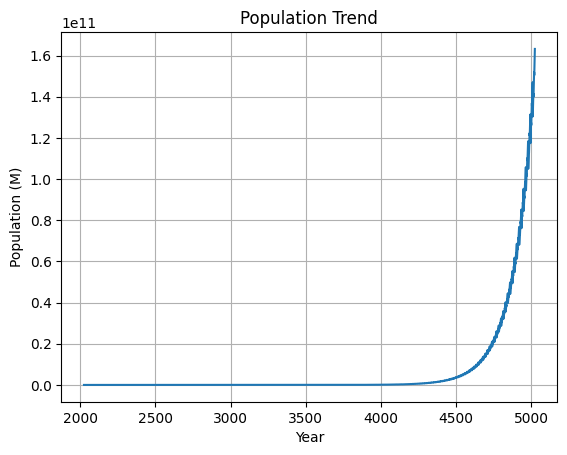

In [10]:
import matplotlib.pyplot as plt

plt.plot(df["Year"], df["Population"])
plt.title("Population Trend")
plt.xlabel("Year")
plt.ylabel("Population (M)")
plt.grid()
plt.show()

In [35]:
import random
import pandas as pd


class Person:
    def __init__(self, age, gender):
        self.age = age
        self.gender = gender
        self.fertile = True

    def age_one_year(self):
        self.age += 1
        if self.age > 30:
            self.fertile = False


import math


def simulate_population(years, initial_population_size):
    population = []
    g = 0.02
    for _ in range(initial_population_size):
        age = random.randint(1, 30)
        gender = random.choice(["Male", "Female"])
        population.append(Person(age, gender))
    population_history = []

    for year in range(years):
        while population:
            pass
        if year % 50 == 0:
            g += 0.000005 * math.pi
        if year % 150 == 0:
            g -= 0.0000005 * math.pi
        current_population = len(population)
        for person in population:
            person.age_one_year()
            if not person.fertile:
                population.remove(person)
        possible_births = g * current_population
        if year % 15 == 0:
            current_population -= 0.3 * 0.34 * current_population
        if year % 30 == 0:
            current_population -= 0.5 * 0.6 * current_population

        for _ in range(int(possible_births)):
            gender = random.choice(["Male", "Female"])
            population.append(Person(age=18, gender=gender))
        population_history.append(current_population)
    return population_history


initial_population_size = 15000
years_to_simulate = 300

population_history = simulate_population(years_to_simulate, initial_population_size)

KeyboardInterrupt: 

In [32]:
df = pd.DataFrame(
    {"Year": range(1, years_to_simulate + 1), "Population": population_history}
)

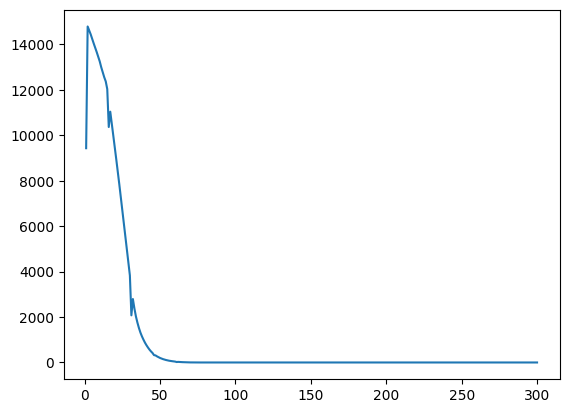

In [34]:
plt.plot(df["Year"], df["Population"])

In [17]:
def countFaults(n: int, logs: list[str]):
    countlist = [logs.count(i) for i in logs]
    x = [i for i in countlist if i >= 3 and "error" in logs[countlist.index(i)]]
    return len(x) // 3


countFaults(
    5, ["s1error", "s2error", "s3success", "s4success", "S4error", "s1error", "s1error"]
)

1

In [32]:
def countFaults(n: int, logs: list[str]) -> int:
    ec = {}
    r = 0

    for log in logs:
        sid = log[:-6]
        status = log[-6:]

        if status == " error":
            ec[sid] = ec.get(sid, 0) + 1
            if ec[sid] == 3:
                r += 1
                ec[sid] = 0
        else:
            ec[sid] = 0

    return r


# Example usage
print(
    countFaults(
        5,
        [
            "s1 error",
            "s2 error",
            "s3 success",
            "s4 success",
            "s4 error",
            "s1 error",
            "s1 error",
            "s1 error",
            "s4 error",
            "s4 error",
            "s4 error",
        ],
    )
)  # Output: 1

2


In [ ]:
import math


def calculateMaximumProfile(cost: list, x):
    l = cost
    total = sum(l)
    res = []
    p = []
    if total <= x:
        return sum([2**i for i in range(len(l))])
    for i in l:
        if i <= x:
            if (sum(res) + i) >= x:
                p.append(2 ** l.index(i))
            else:
                res.append(i)
    return sum(l)

In [ ]:
n = 3, l = [3,4,1],x=8
